# 01 — Nettoyage des données
**Projet LendingClub | Membre 1**

| Étape | Contenu |
|---|---|
| 1 | Chargement accepted + rejected |
| 2 | Filtre loan_status |
| 3 | Suppression Data Leakage ⚠️ |
| 4 | Conversions texte → numérique |
| 5 | IterativeImputer ★ + MissingIndicator ★ |
| 6 | Rapport + Sauvegarde |

## 0. Imports & Chemins

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

RAW_ACCEPTED = '../data/raw/accepted_2007_to_2018Q4.csv'
RAW_REJECTED = '../data/raw/rejected_2007_to_2018Q4.csv'
PROCESSED    = '../data/processed'
os.makedirs(PROCESSED, exist_ok=True)
print('✅ Imports OK — Output:', PROCESSED)

✅ Imports OK — Output: ../data/processed


## 1. Chargement

In [2]:
print('⏳ Chargement accepted ...')
t0 = time.time()
df_acc = pd.read_csv(RAW_ACCEPTED, low_memory=False)
print(f'✅ {df_acc.shape[0]:,} lignes × {df_acc.shape[1]} colonnes  ({time.time()-t0:.0f}s)')
print(f'   Mémoire : {df_acc.memory_usage(deep=True).sum()/1e6:.0f} MB')

⏳ Chargement accepted ...
✅ 2,260,701 lignes × 151 colonnes  (49s)
   Mémoire : 6283 MB


In [3]:
print('⏳ Chargement rejected ...')
df_rej = pd.read_csv(RAW_REJECTED, low_memory=False)
print(f'✅ {df_rej.shape[0]:,} lignes × {df_rej.shape[1]} colonnes')
print('Colonnes rejected :', df_rej.columns.tolist())
display(df_rej.head(3))

⏳ Chargement rejected ...
✅ 27,648,741 lignes × 9 colonnes
Colonnes rejected : ['Amount Requested', 'Application Date', 'Loan Title', 'Risk_Score', 'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length', 'Policy Code']


,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,481xx,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,010xx,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,212xx,MD,1 year,0.0


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,...,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN



Distribution loan_status :
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40


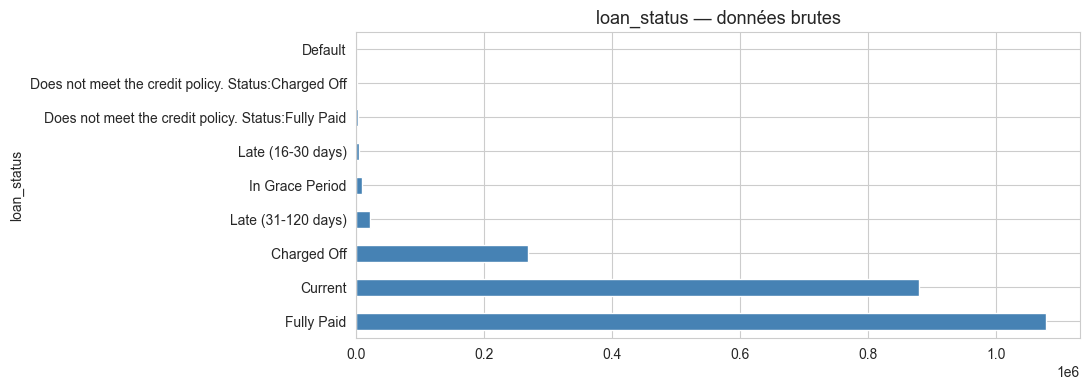

In [4]:
display(df_acc.head(3))
print('\nDistribution loan_status :')
print(df_acc['loan_status'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(11,4))
df_acc['loan_status'].value_counts().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('loan_status — données brutes', fontsize=13)
plt.tight_layout(); plt.savefig(f'{PROCESSED}/01_loan_status_brut.png', dpi=130); plt.show()

## 2. Filtre loan_status → target binaire

Avant  :    2,260,701 lignes
Après  :    1,345,310 lignes  (−40.5%)
  0 Fully Paid   : 1,076,751  (80.0%)
  1 Charged Off  : 268,559  (20.0%)


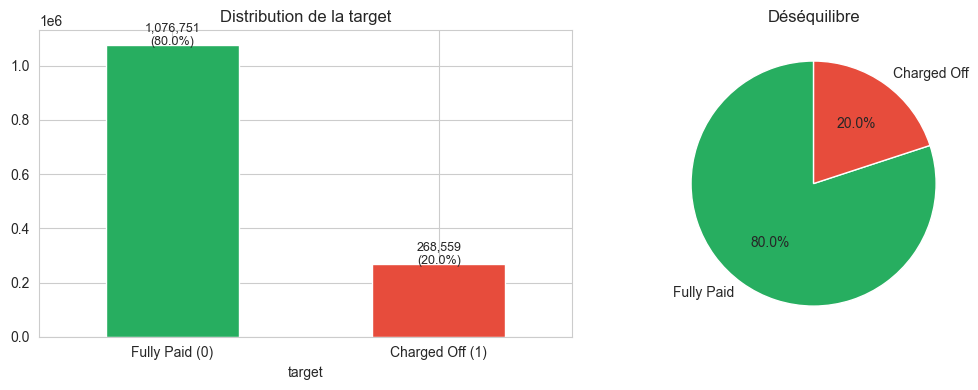

In [5]:
n0  = len(df_acc)
df  = df_acc[df_acc['loan_status'].isin(['Fully Paid','Charged Off'])].copy()
n1  = len(df)
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

print(f'Avant  : {n0:>12,} lignes')
print(f'Après  : {n1:>12,} lignes  (−{(n0-n1)/n0*100:.1f}%)')
vc = df['target'].value_counts()
print(f'  0 Fully Paid   : {vc[0]:,}  ({vc[0]/n1*100:.1f}%)')
print(f'  1 Charged Off  : {vc[1]:,}  ({vc[1]/n1*100:.1f}%)')

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(11,4))
colors = ['#27ae60','#e74c3c']
df['target'].value_counts().plot(kind='bar',ax=ax1,color=colors,rot=0,edgecolor='white')
ax1.set_title('Distribution de la target'); ax1.set_xticklabels(['Fully Paid (0)','Charged Off (1)'])
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():,.0f}\n({p.get_height()/n1*100:.1f}%)',
                 (p.get_x()+p.get_width()/2, p.get_height()+500), ha='center', fontsize=9)
df['target'].value_counts().plot(kind='pie',ax=ax2,colors=colors,
    labels=['Fully Paid','Charged Off'],autopct='%1.1f%%',startangle=90)
ax2.set_title('Déséquilibre'); ax2.set_ylabel('')
plt.tight_layout(); plt.savefig(f'{PROCESSED}/02_target_distribution.png',dpi=130); plt.show()

## 3. Suppression Data Leakage ⚠️

> Ces colonnes n'existent qu'APRÈS le défaut → les garder = 99% d'accuracy ARTIFICIELLE
> → modèle inutilisable en production car l'info n'existe pas au moment de la décision.

In [6]:
LEAKAGE = [
    # Paiements post-octroi
    'out_prncp','out_prncp_inv','total_pymnt','total_pymnt_inv',
    'total_rec_prncp','total_rec_int','total_rec_late_fee',
    'recoveries','collection_recovery_fee',
    'last_pymnt_d','last_pymnt_amnt','next_pymnt_d',
    'last_credit_pull_d','last_fico_range_high','last_fico_range_low',
    # Infos post-défaut
    'debt_settlement_flag','settlement_status','settlement_date',
    'settlement_amount','settlement_percentage','settlement_term',
    'hardship_flag','hardship_type','hardship_reason','hardship_status',
    'hardship_amount','hardship_start_date','hardship_end_date',
    'payment_plan_start_date','hardship_loan_status','hardship_dpd',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount','hardship_last_payment_amount',
    # Identifiants / inutiles
    'id','member_id','url','desc','loan_status','funded_amnt_inv','policy_code',
]
present = [c for c in LEAKAGE if c in df.columns]
print(f'Colonnes leakage supprimées : {len(present)}')
for c in present: print(f'  ✂️  {c}')

Colonnes leakage supprimées : 41
  ✂️  out_prncp
  ✂️  out_prncp_inv
  ✂️  total_pymnt
  ✂️  total_pymnt_inv
  ✂️  total_rec_prncp
  ✂️  total_rec_int
  ✂️  total_rec_late_fee
  ✂️  recoveries
  ✂️  collection_recovery_fee
  ✂️  last_pymnt_d
  ✂️  last_pymnt_amnt
  ✂️  next_pymnt_d
  ✂️  last_credit_pull_d
  ✂️  last_fico_range_high
  ✂️  last_fico_range_low
  ✂️  debt_settlement_flag
  ✂️  settlement_status
  ✂️  settlement_date
  ✂️  settlement_amount
  ✂️  settlement_percentage
  ✂️  settlement_term
  ✂️  hardship_flag
  ✂️  hardship_type
  ✂️  hardship_reason
  ✂️  hardship_status
  ✂️  hardship_amount
  ✂️  hardship_start_date
  ✂️  hardship_end_date
  ✂️  payment_plan_start_date
  ✂️  hardship_loan_status
  ✂️  hardship_dpd
  ✂️  orig_projected_additional_accrued_interest
  ✂️  hardship_payoff_balance_amount
  ✂️  hardship_last_payment_amount
  ✂️  id
  ✂️  member_id
  ✂️  url
  ✂️  desc
  ✂️  loan_status
  ✂️  funded_amnt_inv
  ✂️  policy_code


In [7]:
c0 = df.shape[1]
df.drop(columns=present, inplace=True)
print(f'Colonnes : {c0} → {df.shape[1]}  (−{c0-df.shape[1]})')
print(f'Shape actuelle : {df.shape}')

Colonnes : 152 → 111  (−41)
Shape actuelle : (1345310, 111)


## 4. Conversions texte → numérique

In [8]:
# term : '36 months' → 36
print('term avant:', df['term'].value_counts().to_dict())
df['term'] = df['term'].str.extract(r'(\d+)').astype(float)
print('term après:', df['term'].value_counts().to_dict())

term avant: {' 36 months': 1020743, ' 60 months': 324567}
term après: {36.0: 1020743, 60.0: 324567}


In [9]:
# emp_length : '10+ years' → 10
def parse_emp(s):
    if pd.isna(s): return np.nan
    s = str(s)
    if '10+' in s: return 10.0
    if '< 1'  in s: return 0.5
    d = ''.join(c for c in s if c.isdigit())
    return float(d) if d else np.nan

df['emp_length'] = df['emp_length'].apply(parse_emp)
print('emp_length après :'); print(df['emp_length'].describe())

emp_length après :
count    1.266799e+06
mean     6.008524e+00
std      3.624267e+00
min      5.000000e-01
25%      2.000000e+00
50%      6.000000e+00
75%      1.000000e+01
max      1.000000e+01
Name: emp_length, dtype: float64


In [10]:
# int_rate / revol_util : '13.5%' → 13.5
for col in ['int_rate','revol_util']:
    if col in df.columns and df[col].dtype == object:
        df[col] = df[col].str.replace('%','').str.strip().astype(float)
        print(f'✅ {col} → float  (moy={df[col].mean():.2f})')

In [11]:
# grade : A→1 … G→7
if df['grade'].dtype == object:
    grade_map = {g:i+1 for i,g in enumerate('ABCDEFG')}
    df['grade'] = df['grade'].map(grade_map)
    print('grade → int 1..7 ✅')

# sub_grade : A1→1 … G5→35  (encodage ordinal ★)
if 'sub_grade' in df.columns and df['sub_grade'].dtype == object:
    sub_map = {f'{g}{n}': i*5+n for i,g in enumerate('ABCDEFG') for n in range(1,6)}
    df['sub_grade'] = df['sub_grade'].map(sub_map)
    print('sub_grade → ordinal 1..35 ✅')

In [12]:
# Dates → datetime
for col in ['issue_d','earliest_cr_line']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%b-%Y', errors='coerce')
        print(f'✅ {col} → datetime | ex: {df[col].dropna().iloc[0]}')

print('\nTypes après conversion :')
for t,cnt in df.dtypes.value_counts().items(): print(f'  {str(t):15s}: {cnt}')

✅ issue_d → datetime | ex: 2015-12-01 00:00:00
✅ earliest_cr_line → datetime | ex: 2003-08-01 00:00:00

Types après conversion :
  float64        : 92
  str            : 16
  datetime64[us] : 2
  int64          : 1


## 5. Valeurs manquantes

- **> 50% NaN** → colonne supprimée
- **≤ 50% NaN (numériques)** → **IterativeImputer MICE** ★
- **Catégorielles** → mode
- **MissingIndicator** ★ → flags binaires `_was_nan`

Colonnes avec NaN : 83


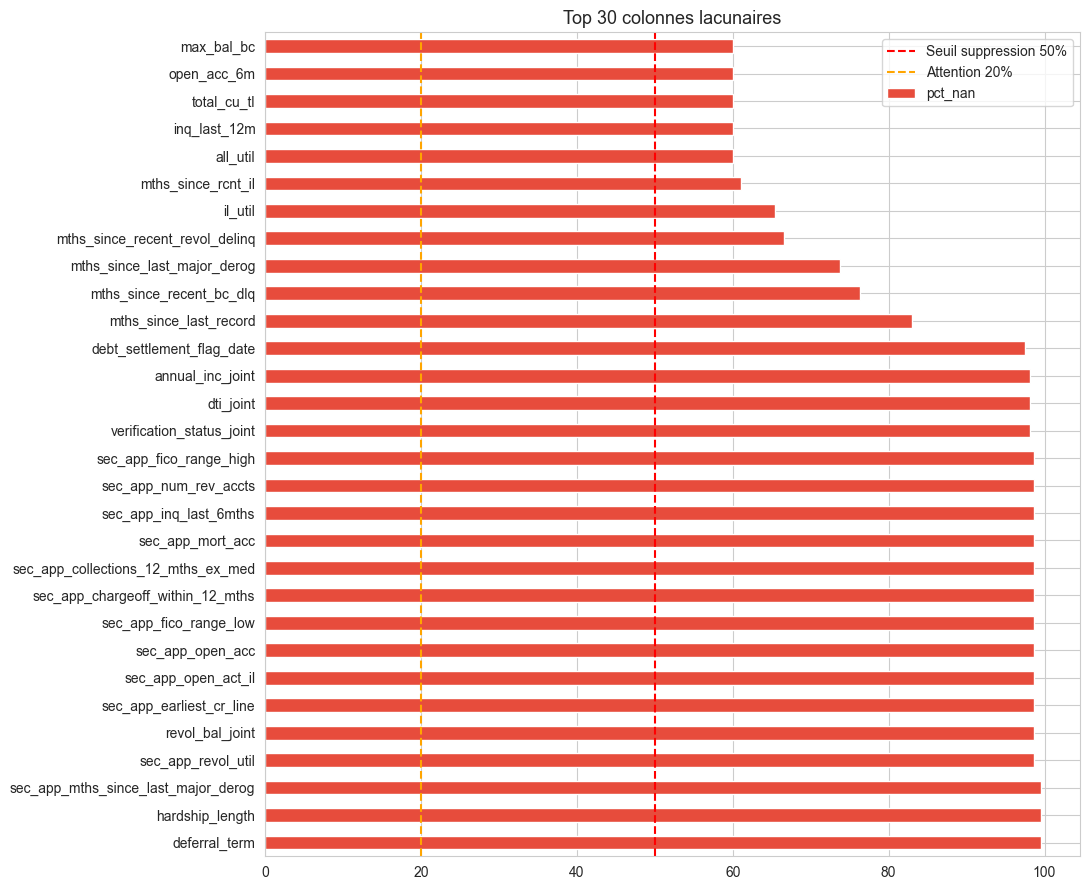

In [13]:
nan_df = pd.DataFrame({'pct_nan': df.isnull().sum()/len(df)*100})
nan_df = nan_df[nan_df['pct_nan']>0].sort_values('pct_nan', ascending=False)
print(f'Colonnes avec NaN : {len(nan_df)}')

top30 = nan_df.head(30)
fig, ax = plt.subplots(figsize=(11,9))
colors = ['#e74c3c' if x>50 else '#e67e22' if x>20 else '#3498db' for x in top30['pct_nan']]
top30['pct_nan'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(50, color='red',    ls='--', lw=1.5, label='Seuil suppression 50%')
ax.axvline(20, color='orange', ls='--', lw=1.5, label='Attention 20%')
ax.set_title('Top 30 colonnes lacunaires', fontsize=13); ax.legend()
plt.tight_layout(); plt.savefig(f'{PROCESSED}/03_missing_values.png',dpi=130); plt.show()

In [14]:
drop_nan = nan_df[nan_df['pct_nan']>50].index.tolist()
print(f'Suppression colonnes >50% NaN : {len(drop_nan)}')
for c in drop_nan: print(f'  ✂️  {c}  ({nan_df.loc[c,"pct_nan"]:.1f}%)')
df.drop(columns=drop_nan, inplace=True)
print(f'Shape : {df.shape}')

Suppression colonnes >50% NaN : 38
  ✂️  deferral_term  (99.6%)
  ✂️  hardship_length  (99.6%)
  ✂️  sec_app_mths_since_last_major_derog  (99.5%)
  ✂️  sec_app_revol_util  (98.6%)
  ✂️  revol_bal_joint  (98.6%)
  ✂️  sec_app_earliest_cr_line  (98.6%)
  ✂️  sec_app_open_act_il  (98.6%)
  ✂️  sec_app_open_acc  (98.6%)
  ✂️  sec_app_fico_range_low  (98.6%)
  ✂️  sec_app_chargeoff_within_12_mths  (98.6%)
  ✂️  sec_app_collections_12_mths_ex_med  (98.6%)
  ✂️  sec_app_mort_acc  (98.6%)
  ✂️  sec_app_inq_last_6mths  (98.6%)
  ✂️  sec_app_num_rev_accts  (98.6%)
  ✂️  sec_app_fico_range_high  (98.6%)
  ✂️  verification_status_joint  (98.1%)
  ✂️  dti_joint  (98.1%)
  ✂️  annual_inc_joint  (98.1%)
  ✂️  debt_settlement_flag_date  (97.5%)
  ✂️  mths_since_last_record  (83.0%)
  ✂️  mths_since_recent_bc_dlq  (76.3%)
  ✂️  mths_since_last_major_derog  (73.7%)
  ✂️  mths_since_recent_revol_delinq  (66.6%)
  ✂️  il_util  (65.4%)
  ✂️  mths_since_rcnt_il  (61.1%)
  ✂️  all_util  (60.0%)
  ✂️  inq_las

In [15]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, MissingIndicator

num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'target']
cat_cols = df.select_dtypes(include='object').columns.tolist()

# MissingIndicator ★ — flags binaires
nan_num = [c for c in num_cols if df[c].isnull().any()]
if nan_num:
    ind    = MissingIndicator(features='missing-only')
    flags  = ind.fit_transform(df[nan_num])
    fnames = [f'{c}_was_nan' for c in np.array(nan_num)[ind.features_]]
    df     = pd.concat([df, pd.DataFrame(flags.astype(int), columns=fnames, index=df.index)], axis=1)
    print(f'✅ MissingIndicator : {len(fnames)} flags ajoutés  ex: {fnames[:4]}')

✅ MissingIndicator : 42 flags ajoutés  ex: ['emp_length_was_nan', 'dti_was_nan', 'inq_last_6mths_was_nan', 'revol_util_was_nan']


In [16]:
# IterativeImputer MICE ★
print('⏳ IterativeImputer (MICE) en cours ...')
t0 = time.time()
imp = IterativeImputer(max_iter=10, random_state=42, verbose=0)
df[num_cols] = pd.DataFrame(imp.fit_transform(df[num_cols]), columns=num_cols, index=df.index)
print(f'✅ Imputation numérique  ({time.time()-t0:.0f}s) — NaN restants: {df[num_cols].isnull().sum().sum()}')

for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
print(f'✅ Imputation catégorielle  — NaN totaux: {df.isnull().sum().sum()}')

⏳ IterativeImputer (MICE) en cours ...
✅ Imputation numérique  (2903s) — NaN restants: 0
✅ Imputation catégorielle  — NaN totaux: 102446


## 6. Rapport & Sauvegarde

In [17]:
print('='*55)
print('   RAPPORT NETTOYAGE — AVANT / APRÈS')
print('='*55)
infos = [
    ('Lignes brutes',                  df_acc.shape[0]),
    ('Lignes finales',                 len(df)),
    ('Colonnes brutes',                df_acc.shape[1]),
    ('Colonnes finales',               df.shape[1]),
    ('Colonnes leakage supprimées',    len(present)),
    ('Colonnes >50% NaN supprimées',   len(drop_nan)),
    ('Flags was_nan ajoutés',          len(fnames) if nan_num else 0),
    ('NaN restants',                   int(df.isnull().sum().sum())),
]
for k,v in infos: print(f'  {k:<38}: {v:>10,}' if isinstance(v,int) else f'  {k:<38}: {v}')
vc = df['target'].value_counts()
print(f'  Target 0 Fully Paid           : {vc[0]:>10,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'  Target 1 Charged Off          : {vc[1]:>10,}  ({vc[1]/len(df)*100:.1f}%)')
print('='*55)

   RAPPORT NETTOYAGE — AVANT / APRÈS
  Lignes brutes                         :  2,260,701
  Lignes finales                        :  1,345,310
  Colonnes brutes                       :        151
  Colonnes finales                      :        115
  Colonnes leakage supprimées           :         41
  Colonnes >50% NaN supprimées          :         38
  Flags was_nan ajoutés                 :         42
  NaN restants                          :    102,446
  Target 0 Fully Paid           :  1,076,751  (80.0%)
  Target 1 Charged Off          :    268,559  (20.0%)


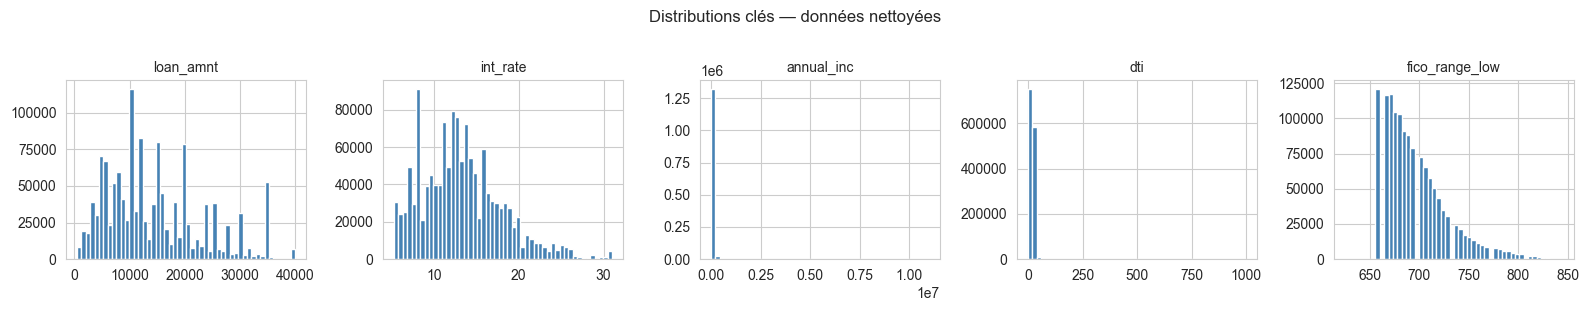

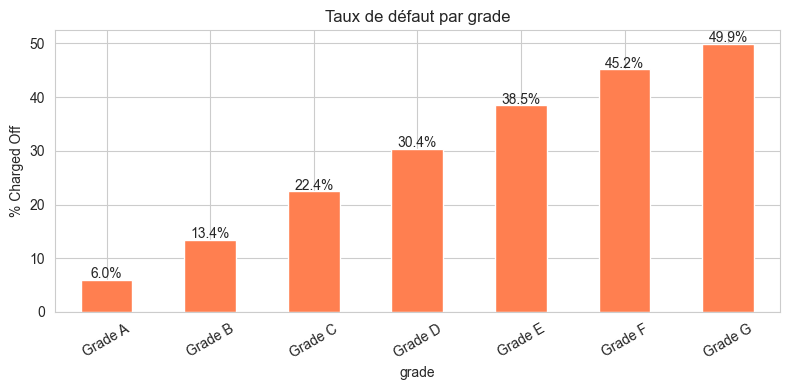

In [20]:
# Distributions clés
key = [c for c in ['loan_amnt','int_rate','annual_inc','dti','fico_range_low'] if c in df.columns]
fig, axes = plt.subplots(1, len(key), figsize=(16,3))
for ax,col in zip(axes,key):
    df[col].hist(ax=ax, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
plt.suptitle('Distributions clés — données nettoyées', y=1.02)
plt.tight_layout(); plt.savefig(f'{PROCESSED}/04_distributions_cles.png',dpi=130); plt.show()

# Taux de défaut par grade
if 'grade' in df.columns:
    fig, ax = plt.subplots(figsize=(8,4))
    rate = df.groupby('grade')['target'].mean()*100
    rate.plot(kind='bar', ax=ax, color='coral', rot=0, edgecolor='white')
    ax.set_xticklabels([f'Grade {x}' for x in rate.index], rotation=30)
    ax.set_title('Taux de défaut par grade'); ax.set_ylabel('% Charged Off')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',(p.get_x()+p.get_width()/2,p.get_height()+0.3),ha='center')
    plt.tight_layout(); plt.savefig(f'{PROCESSED}/05_default_by_grade.png',dpi=130); plt.show()

In [24]:
# Sauvegarde Parquet + CSV
out_pq  = f'{PROCESSED}/lending_clean.parquet'
out_csv = f'{PROCESSED}/lending_clean.csv'
df.to_parquet(out_pq, engine='fastparquet', index=False)
# df.to_parquet(out_pq, index=False)
df.to_csv(out_csv, index=False)
print(f'✅ Parquet : {out_pq}  ({os.path.getsize(out_pq)/1e6:.1f} MB)')
print(f'✅ CSV     : {out_csv}  ({os.path.getsize(out_csv)/1e6:.1f} MB)')
print(f'   Shape  : {df.shape[0]:,} × {df.shape[1]}')
print('\n→ Prochain : 02_feature_eng.ipynb')

✅ Parquet : ../data/processed/lending_clean.parquet  (247.2 MB)
✅ CSV     : ../data/processed/lending_clean.csv  (722.3 MB)
   Shape  : 1,345,310 × 115

→ Prochain : 02_feature_eng.ipynb
